### Imports & general setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.fft import fft, ifft
from scipy.signal import butter
from scipy import signal as sp_signal
import matplotlib as mpl
# mpl.rcParams['figure.dpi'] = 300
# interactive matplotlib in jupyter
%matplotlib ipympl

In [2]:
filename = '43916681'
loaded_data = np.load(f'./stereo_videos/validation_test/{filename}_depth.npz')
keypoints_over_time = loaded_data['pose_data']
kpt_labels = loaded_data['kpt_labels']
print(f'dict keys: {list(loaded_data.keys())}')
print(f'pose_data shape: {keypoints_over_time.shape}')

dict keys: ['pose_data', 'kpt_labels']
pose_data shape: (3908, 26, 3)


In [3]:
# list kpt_labels with indices
for idx, kpt in enumerate(kpt_labels):
    print(idx, kpt)

0 nose
1 left_eye
2 right_eye
3 left_ear
4 right_ear
5 left_shoulder
6 right_shoulder
7 left_elbow
8 right_elbow
9 left_wrist
10 right_wrist
11 left_hip
12 right_hip
13 left_knee
14 right_knee
15 left_ankle
16 right_ankle
17 top_head
18 neck
19 mid_hip
20 left_big_toe
21 right_big_toe
22 left_small_toe
23 right_small_toe
24 left_heel
25 right_heel


In [4]:
LHip = keypoints_over_time[:, 11, :]
RHip = keypoints_over_time[:, 12, :]
# LHip.shape
# Nose = keypoints_over_time[:, 0, :]
# LEye = keypoints_over_time[:, 1, :]
# REye = keypoints_over_time[:, 2, :]

RAnkle = keypoints_over_time[:, 16, :]

In [40]:
signal = RAnkle 
confidence = RAnkle[:, 2]

print(signal.shape)
print(confidence.shape)

(690, 3)
(690,)


### Replacing outliers

1. find outliers
2. replace them with NaN
3. calculate what should replace them

In [17]:
def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

In [41]:
mean = np.mean(confidence)
std = np.std(confidence)
max = np.max(confidence)
print(f'Mean: {mean}, Std: {std}, Max: {max}')

mean_plot = np.ones_like(confidence) * mean
std_plot_p = mean_plot + std
std_plot_n = mean_plot - std
std_plot_p2 = mean_plot + 2 * std
std_plot_n2 = mean_plot - 2 * std
attributes = [std_plot_p, std_plot_n, std_plot_p2, std_plot_n2]

Mean: 0.865031111413154, Std: 0.053220017326220025, Max: 1.0086452960968018


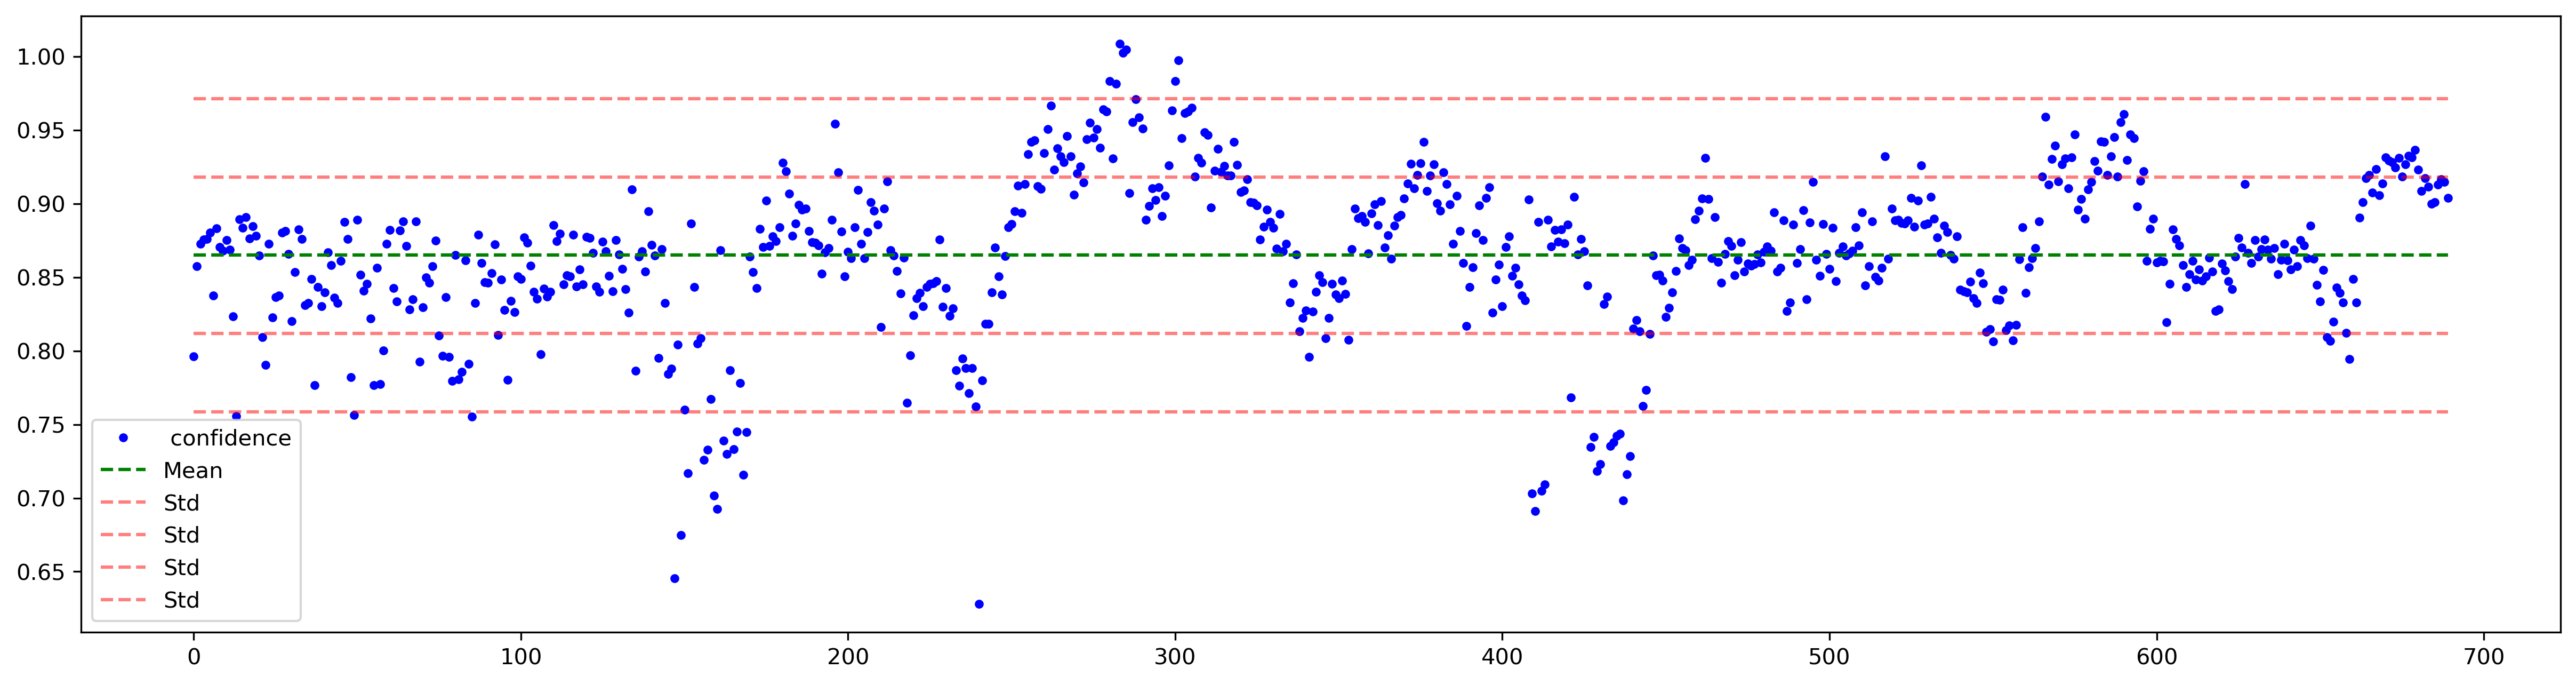

In [42]:
plt.figure(figsize=(20, 5))
plt.plot(confidence,'b.', label=' confidence')
# plt.plot(og[:,2],'rs', alpha=0.2, label='Original confidence')

plt.plot(mean_plot, 'g--', label='Mean')
# plt.plot(std_plot_p, 'r--', label='Std')
# plt.plot(std_plot_n, 'r--')

for attr in attributes:
    plt.plot(attr, 'r--', alpha=0.5, label='Std')

plt.legend()

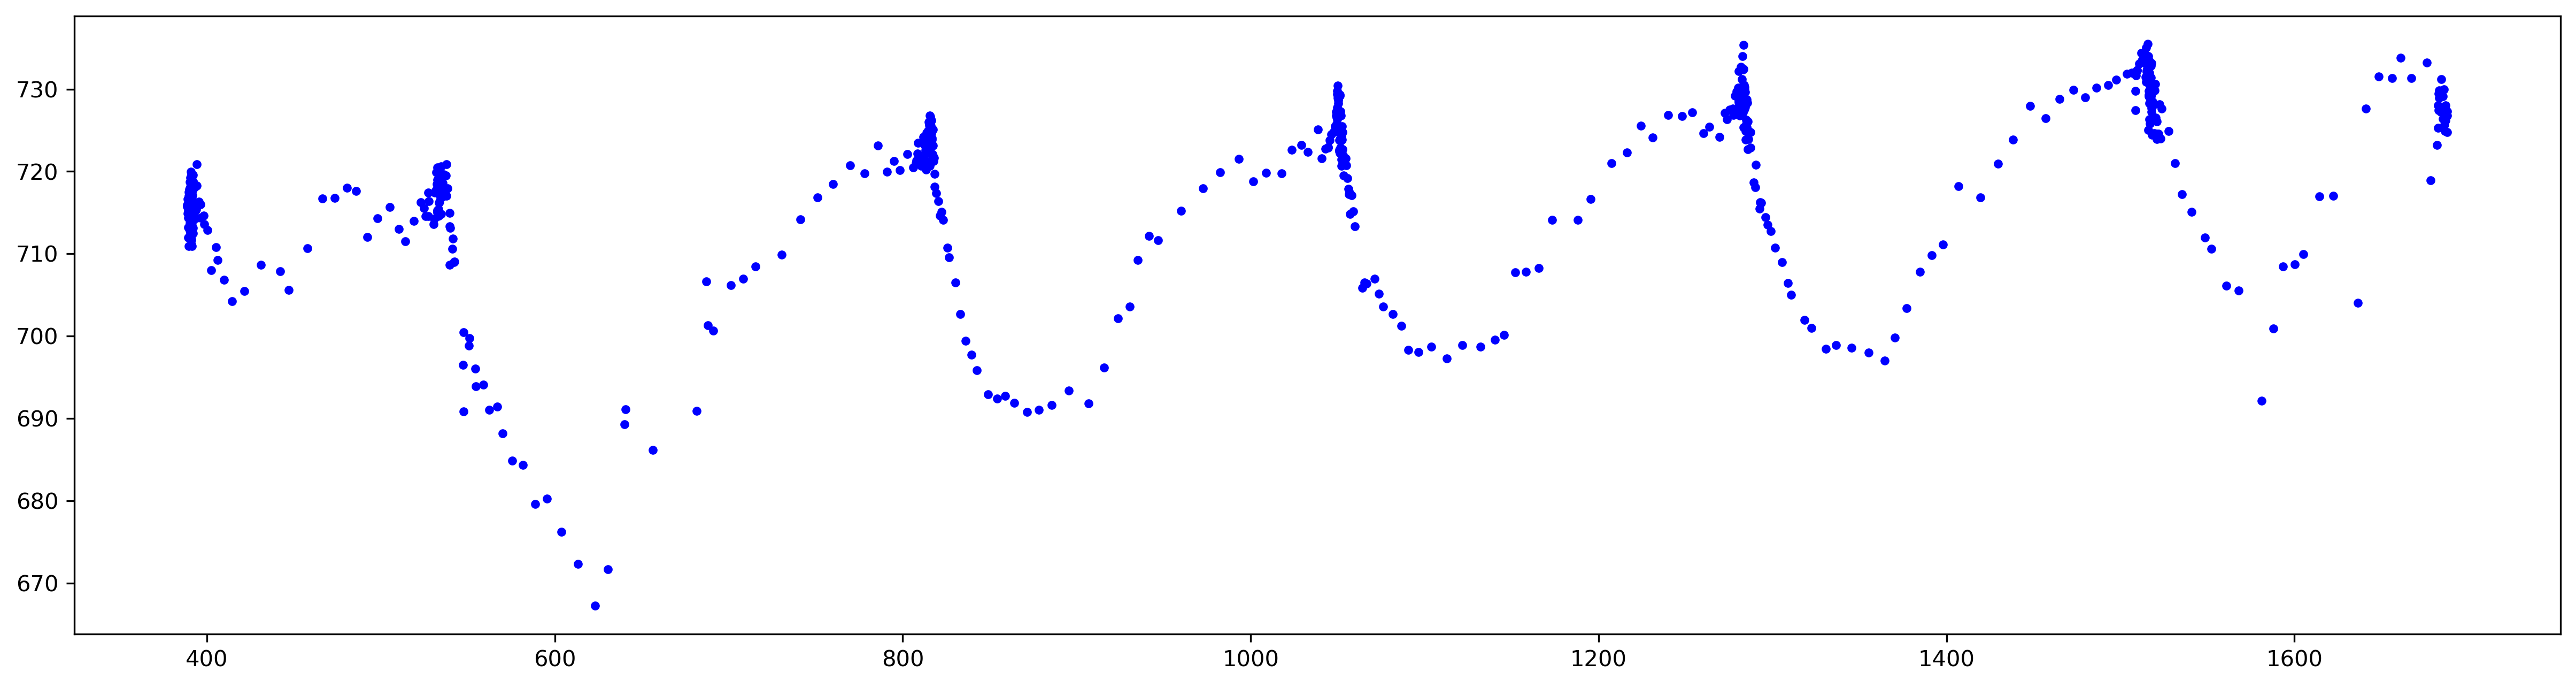

In [43]:
plt.figure(figsize=(20, 5))
plt.plot(RAnkle[:, 0], RAnkle[:, 1], 'b.', label='RAnkle')

In [61]:
confidence_thr = 0.8
confidence_max = np.max(Nose[:,2])

for i in range(30):
    for ind, (x, y, conf) in enumerate(Nose):
        # print(ind, x, y, conf)

        # there is an outlier
        if conf < confidence_thr * confidence_max and ind >0 and ind < len(Nose) - 1:
            # Nose[ind, 0] = (Nose[ind-1, 0] + Nose[ind+1, 0]) / 2
            # Nose[ind, 1] = (Nose[ind-1, 1] + Nose[ind+1, 1]) / 2
            Nose[ind, 2] = (Nose[ind-1, 2] + Nose[ind+1, 2]) / 2

            # value[0] = np.nan
            # value[1] = np.nan

### Filtering

In [4]:
def filter_keypoint(keypoint: np.array, title: str, fr=60, create_diagram=False) -> np.array:
    """
    Perfortm FFT and low-pass filtering on a single keypoint (e.g.: left elbow, (N, (x,y,conf))).

    Returns the filetered keypoint coordinates (and confidence) in the original shape (N, 3).
    """

    # x and y coordinates
    kp_x = keypoint[:, 0]
    kp_y = keypoint[:, 1]

    filtered_keypoint = np.empty_like(keypoint)
    filtered_x, filtered_y = np.empty_like(kp_x), np.empty_like(kp_y)

    # time
    t = np.arange(0, keypoint.shape[0], 1) / fr

    # filtering parameters
    order = 2
    lowcut = 2  # cut fr for lowpass
    # highpass = 5 # cut fr for highpass
    # bandpass = [0.1, 5]
    b, a = butter(order, lowcut, fs=fr, btype="low", analog=False)

    for coords in [kp_x, kp_y]:

        original = coords.copy()

        # replace NaN values with zeros
        if np.isnan(coords).any():
            print("NaN values found in keypoint data. Replacing with zeros.")
            coords[np.isnan(coords)] = 0

        # filtered x or y coords
        filtered_coord = sp_signal.filtfilt(b, a, coords)

        if np.array_equiv(coords, kp_x):
            filtered_x = filtered_coord
            subtitle = "x coordinate"
            yl = 0.1

        elif np.array_equiv(coords, kp_y):
            filtered_y = filtered_coord
            subtitle = "y coordinate"
            yl = 0.005

        if create_diagram:
            plt.figure(figsize=(15, 3))
            plt.title(subtitle)

            plt.suptitle(f"FFT of {title} Keypoint", fontsize=16)
            colors = ["r", "b"]

            # perform FFT on each coordinate(x or y), plot results
            for i, signal in enumerate([filtered_coord, original]):

                X = fft(signal)
                N = len(X)
                n = np.arange(N)
                T = N / 60
                freq = n / T
                plt.subplot(1, 2, 1)
                plt.plot(
                    freq,
                    np.abs(X),
                    colors[i],
                    label=f'{title} {["Filtered", "Original"][i]}',
                    alpha=[1, 0.5][i],
                )
                plt.tight_layout()

            plt.xlabel("Freq (Hz)")
            plt.ylabel("FFT Amplitude |X(freq)|")
            plt.xlim(0, fr / 2)
            ylim = max(np.abs(X) * yl)
            plt.ylim(0, ylim)
            plt.legend(["Filtered", "Original"])

            # plot the original and iFFT signals
            plt.subplot(122)
            plt.plot(t, ifft(X), "r")
            plt.plot(t, original, "b--")
            plt.xlabel("Time (s)")
            plt.ylabel("Amplitude [px]")
            plt.legend(["iFFT", "Original"])
            plt.tight_layout()
            plt.show()

            # plot the original and filtered signals
            plt.figure(figsize=(15, 3))
            plt.plot(t, original, "b--", label="Original")
            plt.plot(t, filtered_coord, "r", label="Filtered")
            plt.xlabel("Time (s)")
            plt.ylabel("Amplitude [px]")
            plt.legend()
            plt.grid()
            plt.show()

        # stack filtered coords, use original confidence
        filtered_keypoint = np.stack([filtered_x, filtered_y, keypoint[:, 2]], axis=1)

    return filtered_keypoint


# filtered_coords = filter_keypoint(RAnkle, "Test", fr=60, create_diagram=True)

c:\Users\unger\miniconda3\envs\stereo_vision\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\unger\miniconda3\envs\stereo_vision\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


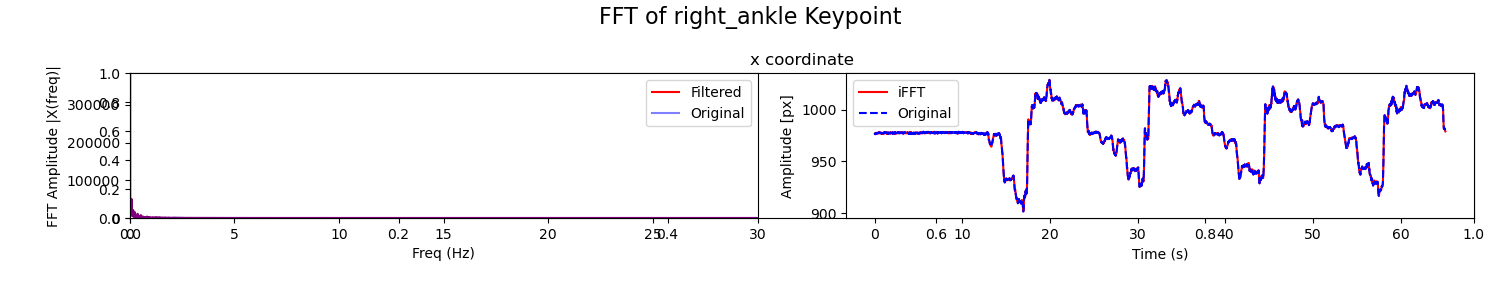

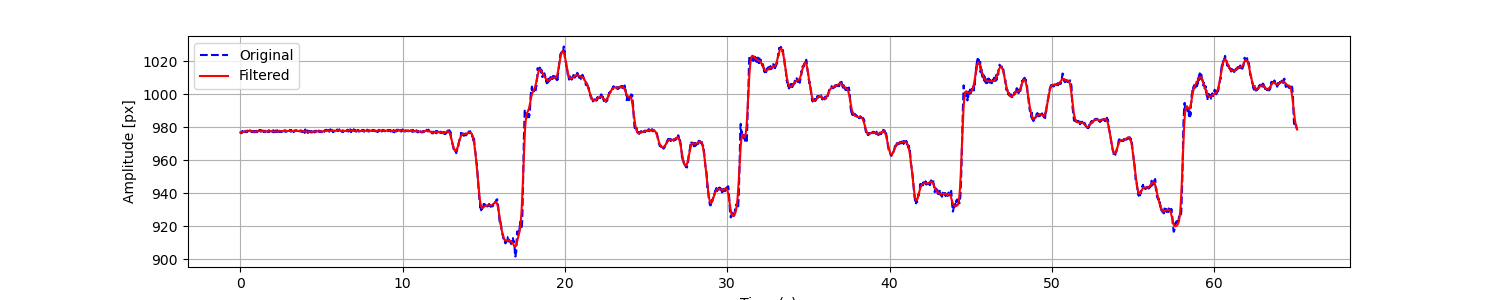

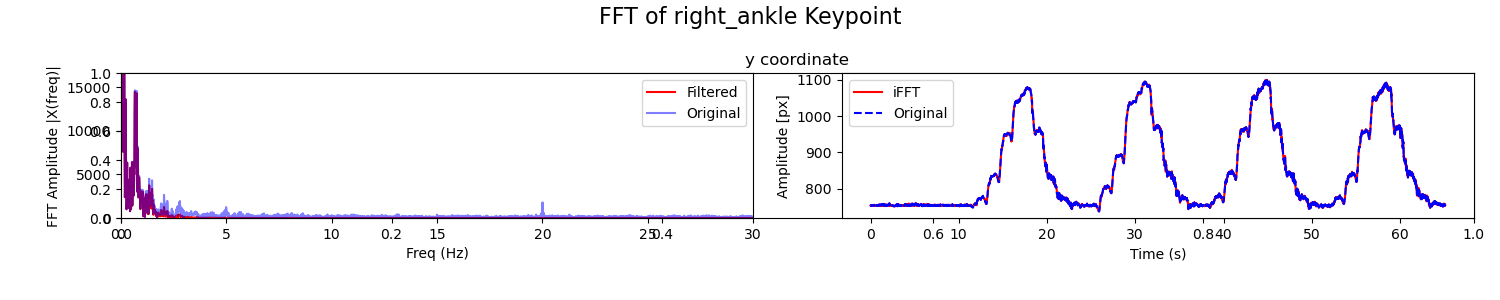

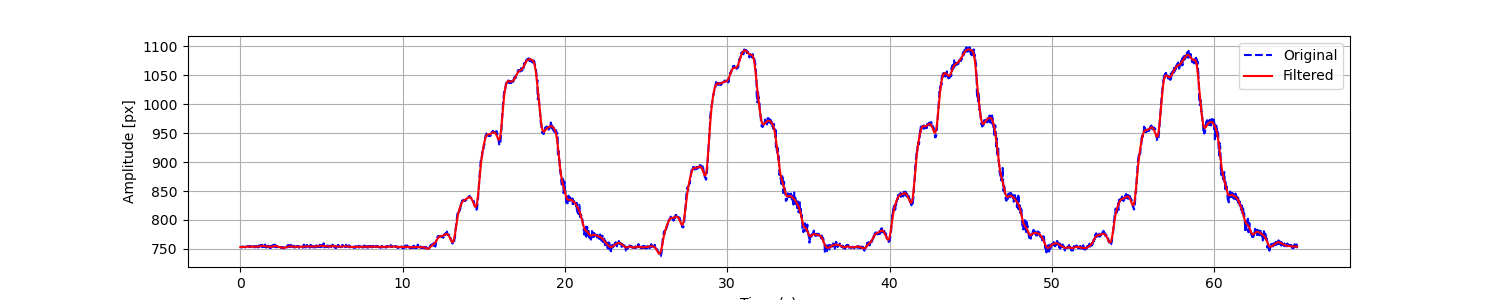

In [6]:
kpt_idx = 16
plt.close('all')
_ = filter_keypoint(keypoints_over_time[:,kpt_idx,:],kpt_labels[kpt_idx],60,True)

In [11]:
from tqdm import tqdm


# filename = 'ken_walking_side_short'
# keypoints_over_time = np.load(f'./saved_coords/validation_test/{filename}.npy')
# keypoints_over_time.shape


filtered_data = []

for keypoint_id, keypoint in enumerate(keypoints_over_time.transpose(1, 0, 2)):

    # print(f'input shape: {keypoint.shape},  keypoint_id: {keypoint_id}')
    result = filter_keypoint(keypoint, f'{keypoint_id}', fr=60, create_diagram=False)
    # filtered_data = np.stack([filtered_data, result], axis=0)
    filtered_data.append(result)

    # print(f'output shape: {result.shape}')
    
    # if keypoint_id == 2:
    #     break


filtered_data = np.array(filtered_data).transpose(1, 0, 2)
print("Filtered data shape:", np.array(filtered_data).shape)

Filtered data shape: (3908, 27, 3)


####  create a new keypoint for tracking the scale
mid_heel = (left_heel + right_heel)/2 

In [12]:
left_heel = filtered_data[:,24,:]
right_heel = filtered_data[:,25,:]

mid_heel = (left_heel + right_heel)/2

# add the new keypoint to the rest
filtered_data = np.concat((filtered_data, np.expand_dims(mid_heel, axis=1)), axis=1)
print(f'filtered keypoints shape: {filtered_data.shape}')

# for i in range(5):
#     print(f'left: {left_heel[i]},   right: {right_heel[i]}, mid: {mid_heel[i]}')

filtered keypoints shape: (3908, 28, 3)


mean: 1.659 m, std: 0.011 m


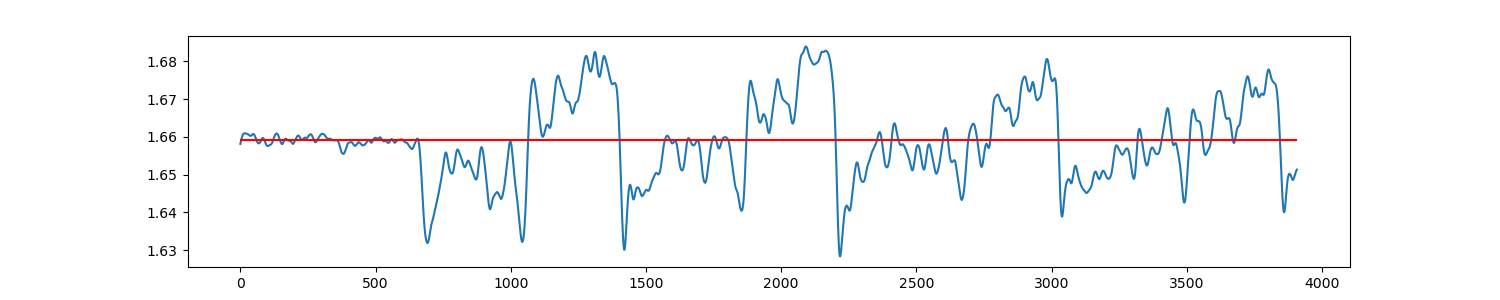

In [ ]:
# participant height in meters
HEIGHT_METERS = 1.8

# y coords of the top_head and mid_heel keypoints
top_head_y = filtered_data[:,17,1]
mid_heel_y = mid_heel[:,1]

# participant height in pixels
height_px = (mid_heel_y - top_head_y)


# how many meters one pixel is in each frame
scale = HEIGHT_METERS/height_px



# check with nose height
nose = filtered_data[:,0,:]
nose_height_px = mid_heel[:,1] - nose[:,1]
nose_height_m = np.multiply(nose_height_px,scale)
plt.figure(figsize=(15,3))
plt.plot(nose_height_m)
plt.hlines(np.mean(nose_height_m), 0, nose_height_m.shape[0], 'r')
plt.hlines(np.std(nose_height_m), 0, nose_height_m.shape[0], 'g')
plt.hlines(np.std(nose_height_m), 0, nose_height_m.shape[0], 'r')

print(f"mean: {np.mean(nose_height_m):.3f} m, std: {np.std(nose_height_m):.3f} m")

In [39]:
nose.shape, scale.shape, np.multiply(nose[:,1],scale).shape

((3908, 3), (3908,), (3908,))

## Playback

In [13]:
# visualize keypoints
import cv2
import time

video_path = f'./stereo_videos/validation_test/{filename}.avi'
cap = cv2.VideoCapture(video_path)
total_num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

keypoints_over_time = filtered_data



frame_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame_idx >= keypoints_over_time.shape[0]:
        break

    # Overlay all keypoints for this frame
    for ind, (x, y, confidence) in enumerate(keypoints_over_time[frame_idx]):
        # Ensure x and y are finite numbers before drawing
        if np.isfinite(x) and np.isfinite(y):
            try: 
                # if ind in []:
                cv2.circle(frame, (int(x), int(y)), 2, (255,0,0), 5)
                    # cv2.putText(frame, f'LHip: {confidence:.2f}', (int(x) + 10, int(y) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
                # else:
                #     cv2.circle(frame, (int(round(x)), int(round(y))), 4, (0, int(confidence * 255), 255 - int(255 * confidence)), -1)
            except Exception as e:
                print(f"Error drawing circle for keypoint {ind}: x={x}, y={y}, confidence={confidence}, error={e}")

    cv2.putText(frame, f'Frame: {frame_idx + 1}/{total_num_frames}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # Draw a color gradient for confidence levels            
    # for i in range(0,11,1):
    #     cv2.circle(frame, (50, 500-i*30), 4, (0, i*255/10,255-255*i/10), -1)  
    #     cv2.putText(frame, f'{i/10}', (60, 500-i*30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # Resize and display the frame
    cv2.imshow('Coords',cv2.resize(frame, (int(frame.shape[1] / 1.5), int(frame.shape[0] / 1.5))))
    time.sleep(0.05)
    # out.write(frame)  # Uncomment to save output

    # press 'q' to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    frame_idx += 1

cap.release()
# out.release()
cv2.destroyAllWindows()

In [ ]:
# visualize keypoints and confidences
import cv2
import time

video_path = f'./stereo_videos/validation_test/{filename}.avi'
cap = cv2.VideoCapture(video_path)
total_num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

keypoints_over_time = filtered_data



frame_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame_idx >= keypoints_over_time.shape[0]:
        break

    # Overlay all keypoints for this frame
    for ind, (x, y, confidence) in enumerate(keypoints_over_time[frame_idx]):
        # Ensure x and y are finite numbers before drawing
        if np.isfinite(x) and np.isfinite(y):
            try: 
                if ind in []:
                    cv2.circle(frame, (int(x), int(y)), 5, (255,0,0), 5)
                    # cv2.putText(frame, f'LHip: {confidence:.2f}', (int(x) + 10, int(y) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
                else:
                    cv2.circle(frame, (int(round(x)), int(round(y))), 4, (0, int(confidence * 255), 255 - int(255 * confidence)), -1)
            except Exception as e:
                print(f"Error drawing circle for keypoint {ind}: x={x}, y={y}, confidence={confidence}, error={e}")

    cv2.putText(frame, f'Frame: {frame_idx + 1}/{total_num_frames}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # Draw a color gradient for confidence levels            
    for i in range(0,11,1):
        cv2.circle(frame, (50, 500-i*30), 4, (0, i*255/10,255-255*i/10), -1)  
        cv2.putText(frame, f'{i/10}', (60, 500-i*30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # Resize and display the frame
    cv2.imshow('Coords',cv2.resize(frame, (int(frame.shape[1] / 1.5), int(frame.shape[0] / 1.5))))
    time.sleep(0.05)
    # out.write(frame)  # Uncomment to save output

    # press 'q' to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    frame_idx += 1

cap.release()
# out.release()
cv2.destroyAllWindows()